In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

sns.set_style("whitegrid")

# ==========================================
# 2. LOAD DATA
# ==========================================

df = pd.read_csv("cleaned_selangor_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (110789, 6)


,property_type,district,month_year_of_transaction_date,tenure,main_floor_area,transaction_price
0,1 - 1 1/2 Storey Semi-Detached,Gombak,August 2021,Leasehold,74.0,370000
1,1 - 1 1/2 Storey Semi-Detached,Gombak,May 2021,Leasehold,74.0,405000
2,1 - 1 1/2 Storey Semi-Detached,Gombak,July 2021,Leasehold,94.0,380000
3,1 - 1 1/2 Storey Semi-Detached,Gombak,February 2024,Leasehold,157.0,750000
4,1 - 1 1/2 Storey Semi-Detached,Gombak,October 2023,Leasehold,74.0,315000


In [2]:
# Dataset info
df.info()

# Summary statistics
df.describe(include='all')

# Missing values
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": round(df.isnull().mean()*100,2)
})

print(missing.sort_values("Missing %", ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110789 entries, 0 to 110788
Data columns (total 6 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   property_type                   110789 non-null  object 
 1   district                        110789 non-null  object 
 2   month_year_of_transaction_date  110789 non-null  object 
 3   tenure                          110789 non-null  object 
 4   main_floor_area                 70951 non-null   float64
 5   transaction_price               110789 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 5.1+ MB
                                Missing Count  Missing %
main_floor_area                         39838      35.96
property_type                               0       0.00
district                                    0       0.00
month_year_of_transaction_date              0       0.00
tenure                                      0  

In [3]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

# View duplicates
df[df.duplicated()].head()

Duplicate rows: 14919


,property_type,district,month_year_of_transaction_date,tenure,main_floor_area,transaction_price
199,1 - 1 1/2 Storey Semi-Detached,Hulu Selangor,March 2022,Leasehold,195.0,97000
205,1 - 1 1/2 Storey Semi-Detached,Hulu Selangor,June 2022,Leasehold,100.0,97000
207,1 - 1 1/2 Storey Semi-Detached,Hulu Selangor,July 2022,Leasehold,69.0,97000
209,1 - 1 1/2 Storey Semi-Detached,Hulu Selangor,March 2022,Leasehold,195.0,97000
211,1 - 1 1/2 Storey Semi-Detached,Hulu Selangor,July 2022,Leasehold,69.0,97000


## **TRANSACTION PRICE DISTRIBUTION** ##

**HISTOGRAM**

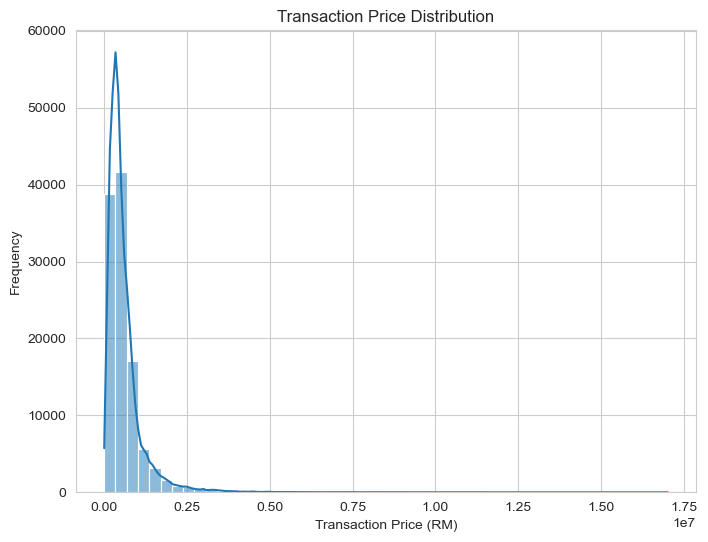

In [43]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["transaction_price"],
    bins=50,
    kde=True
)

plt.title("Transaction Price Distribution")
plt.xlabel("Transaction Price (RM)")
plt.ylabel("Frequency")

plt.show()

**LOG-TRANSFORMED PRICE**

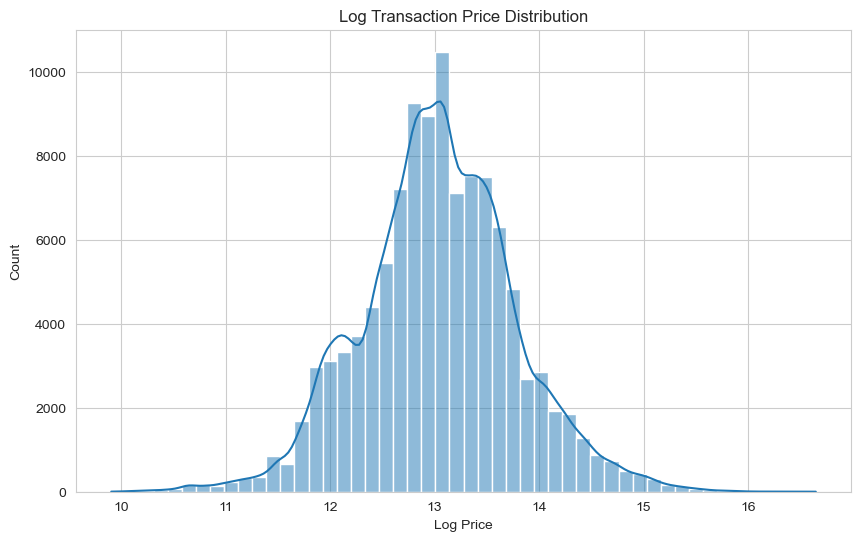

In [10]:
df["log_price"] = np.log1p(df["transaction_price"])

plt.figure(figsize=(10,6))

sns.histplot(
    df["log_price"],
    bins=50,
    kde=True
)

plt.title("Log Transaction Price Distribution")
plt.xlabel("Log Price")

plt.show()

**BOXPLOT**

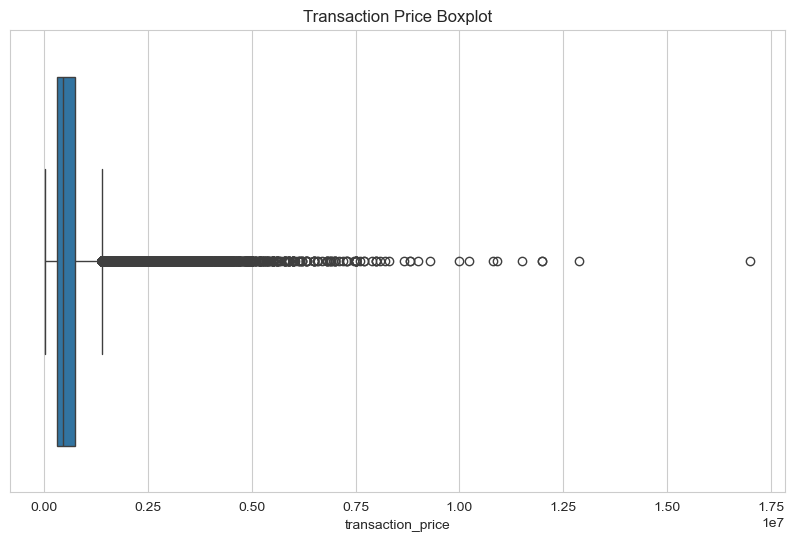

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["transaction_price"]
)

plt.title("Transaction Price Boxplot")

plt.show()

**PRICE SKEWNESS**

In [12]:
print("Skewness:", skew(df["transaction_price"]))

Skewness: 4.325431097841648


## **MAIN FLOOR AREA DISTRIBUTION** ##

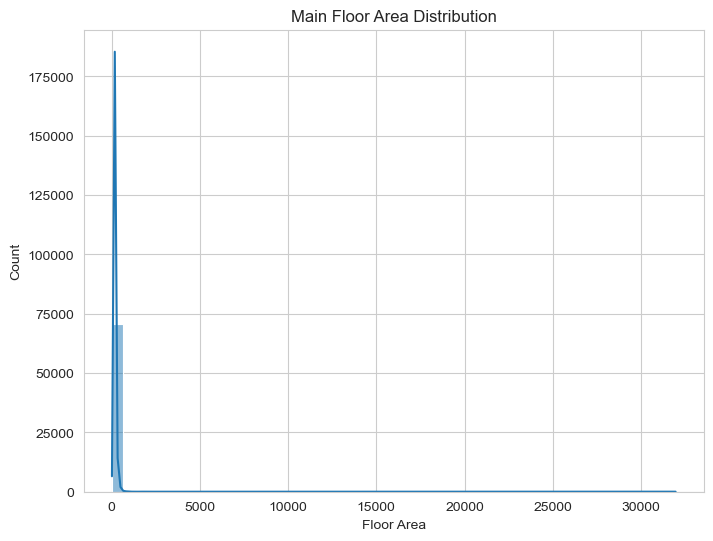

In [44]:
plt.figure(figsize=(8,6))

sns.histplot(
    df["main_floor_area"].dropna(),
    bins=50,
    kde=True
)

plt.title("Main Floor Area Distribution")
plt.xlabel("Floor Area")

plt.show()

**AREA BOXPLOT**

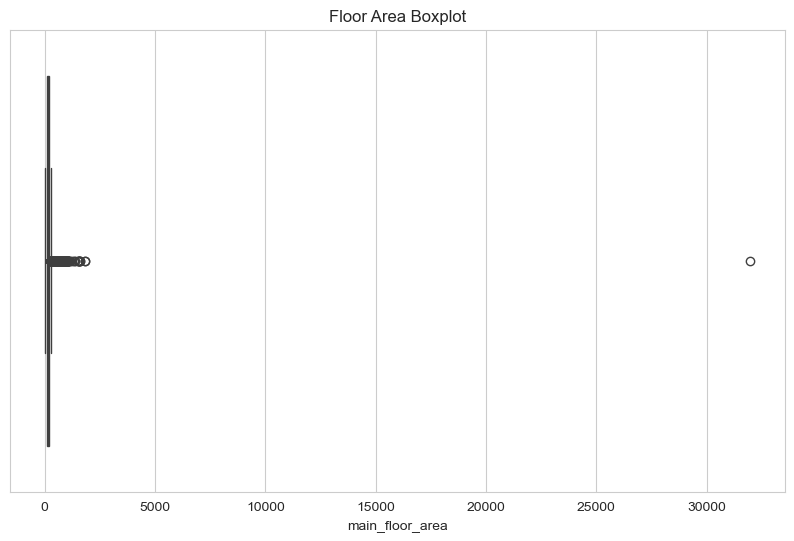

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["main_floor_area"]
)

plt.title("Floor Area Boxplot")

plt.show()

## **OUTLIER DETECTION USING IQR** ##

**PRICE**

In [15]:
Q1 = df["transaction_price"].quantile(0.25)
Q3 = df["transaction_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

price_outliers = df[
    (df["transaction_price"] < lower) |
    (df["transaction_price"] > upper)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 7547


In [16]:
price_outliers.sort_values(
    "transaction_price",
    ascending=False
).head(20)

,property_type,district,month_year_of_transaction_date,tenure,main_floor_area,transaction_price,log_price
87124,Detached,Gombak,January 2024,Leasehold,1387.0,17000000,16.648724
87896,Detached,Hulu Langat,July 2022,Freehold,1561.0,12880000,16.371186
87905,Detached,Hulu Langat,June 2025,Freehold,1807.0,12000000,16.300417
99467,Low-Cost Flat,Hulu Langat,January 2023,Leasehold,NaN,12000000,16.300417
87904,Detached,Hulu Langat,September 2022,Freehold,1807.0,11500000,16.257858
90419,Detached,Petaling,December 2021,Leasehold,222.0,10905000,16.204732
89455,Detached,Petaling,February 2024,Leasehold,1573.0,10800000,16.195057
90314,Detached,Petaling,January 2024,Leasehold,1250.0,10239000,16.141715
65436,Condominium/Apartment,Gombak,February 2023,Leasehold,NaN,9999000,16.117996
89935,Detached,Petaling,January 2025,Freehold,689.0,9300000,16.045525


**AREA OUTLIERS**

In [17]:
Q1 = df["main_floor_area"].quantile(0.25)
Q3 = df["main_floor_area"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

area_outliers = df[
    (df["main_floor_area"] < lower) |
    (df["main_floor_area"] > upper)
]

print("Area Outliers:", len(area_outliers))

Area Outliers: 3405


## **DISTRICT ANALYSIS** ##

**NUMBER OF TRANSACTIONS**

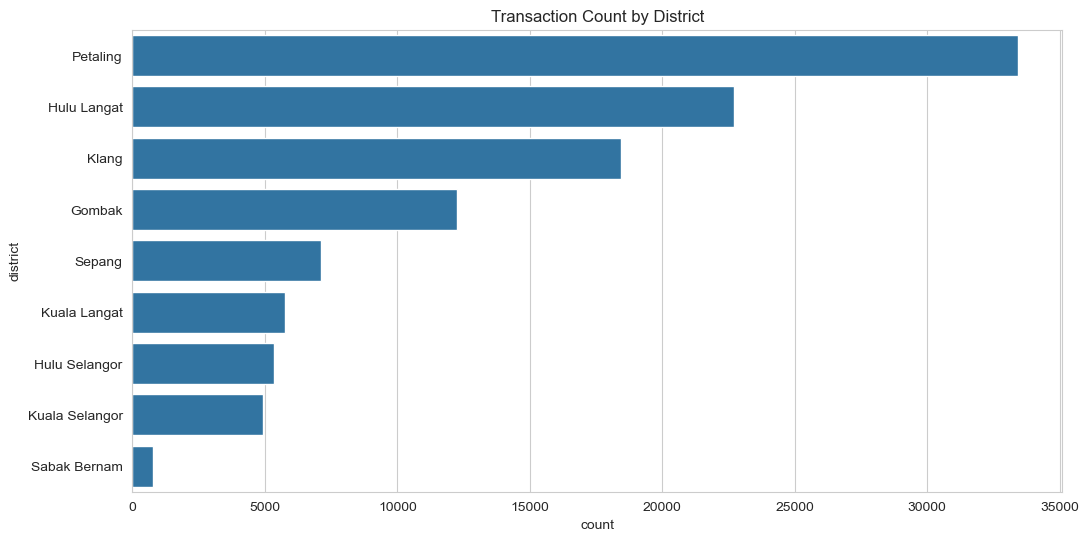

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="district",
    order=df["district"].value_counts().index
)

plt.title("Transaction Count by District")

plt.show()

**AVERAGE PRICE BY DISTRICT**

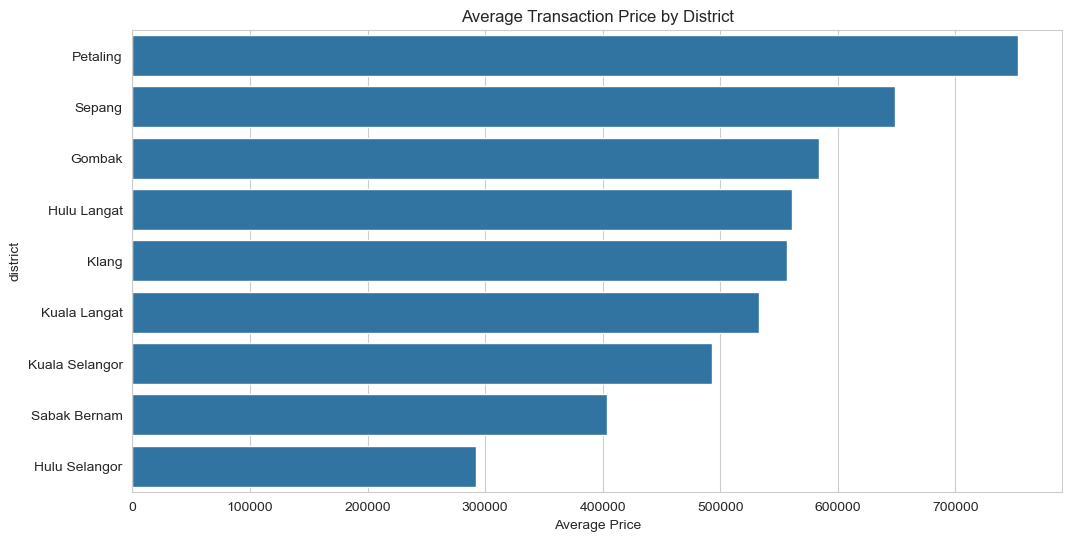

In [19]:
district_price = (
    df.groupby("district")["transaction_price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=district_price.values,
    y=district_price.index
)

plt.title("Average Transaction Price by District")
plt.xlabel("Average Price")

plt.show()

**PRICE DISTRIBUTION BY DISTRICT**

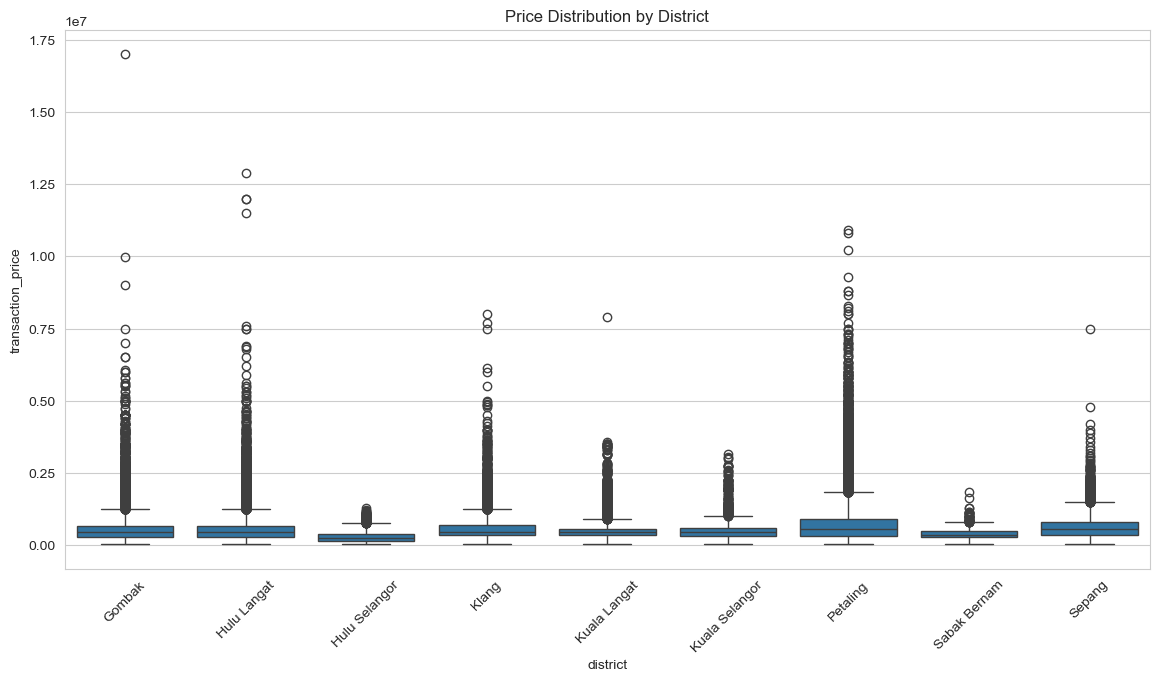

In [20]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="district",
    y="transaction_price"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by District")

plt.show()

## **TENURE ANALYSIS** ##

**TENURE COUNTS**

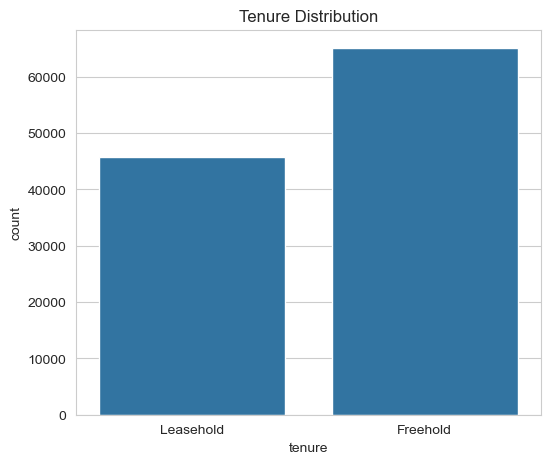

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="tenure"
)

plt.title("Tenure Distribution")

plt.show()

**AVERAGE PRICE BY TENURE**

In [22]:
df.groupby("tenure")["transaction_price"].mean()

tenure
Freehold     677234.178187
Leasehold    509233.075795
Name: transaction_price, dtype: float64

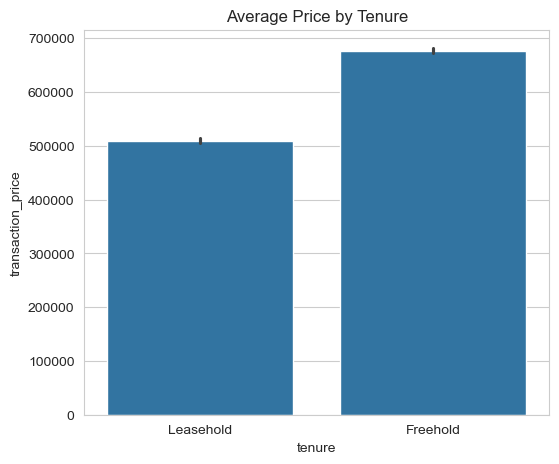

In [40]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="tenure",
    y="transaction_price",
    estimator=np.mean
)

plt.title("Average Price by Tenure")

plt.show()

## **PROPERTY TYPE ANALYSIS** ##

**VOLUME**

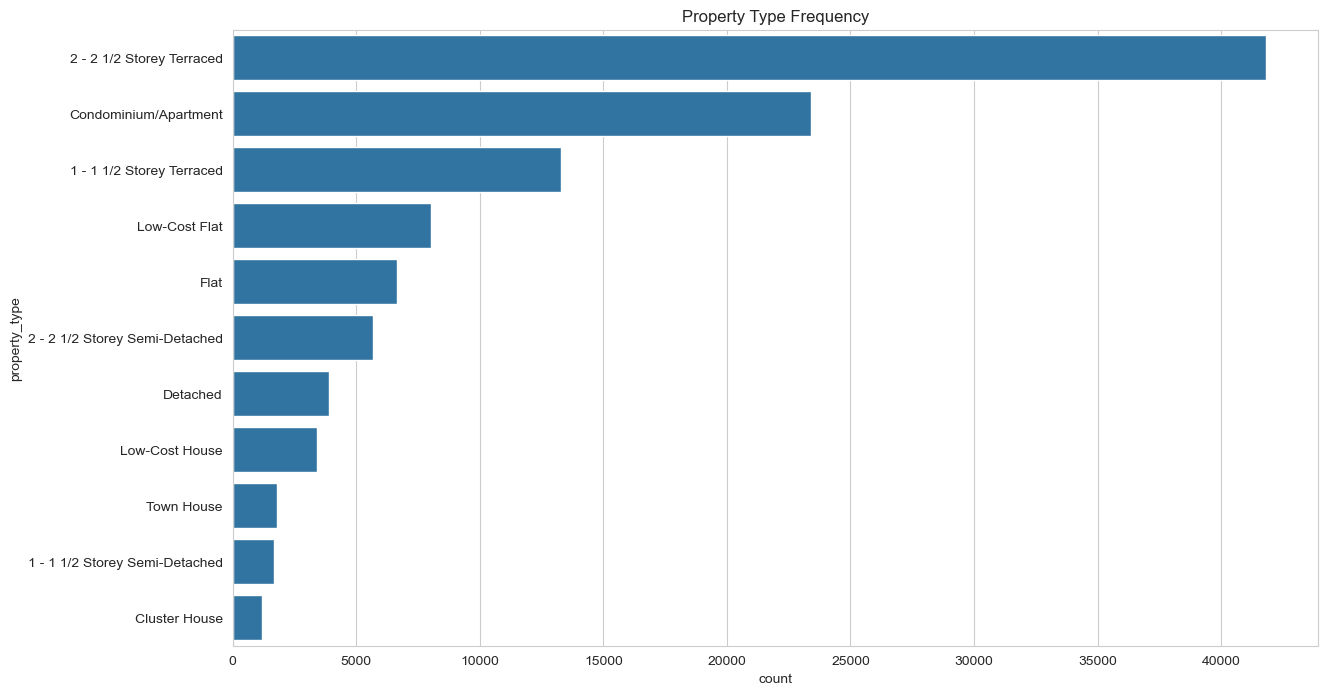

In [24]:
plt.figure(figsize=(14,8))

sns.countplot(
    data=df,
    y="property_type",
    order=df["property_type"].value_counts().index
)

plt.title("Property Type Frequency")

plt.show()

**AVERAGE PRICE**

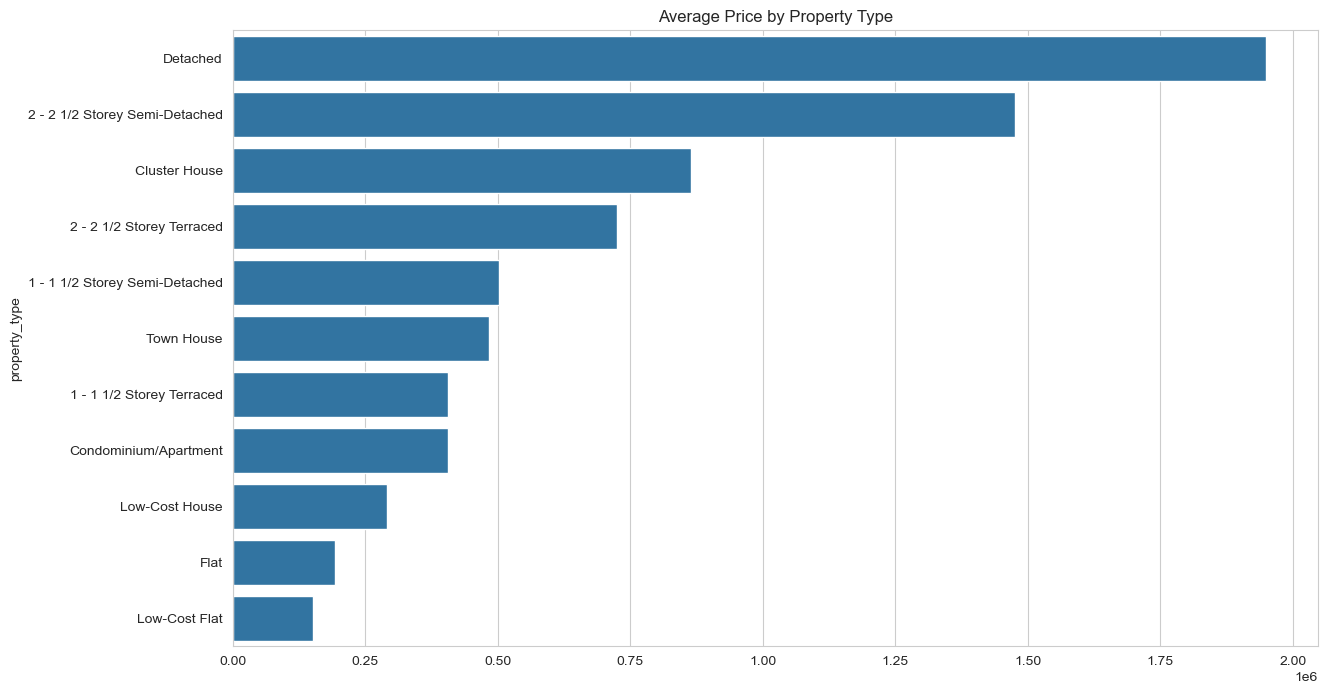

In [25]:
property_avg = (
    df.groupby("property_type")["transaction_price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,8))

sns.barplot(
    x=property_avg.values,
    y=property_avg.index
)

plt.title("Average Price by Property Type")

plt.show()

## **AREA vs PRICE RELATIONSHIP** ##

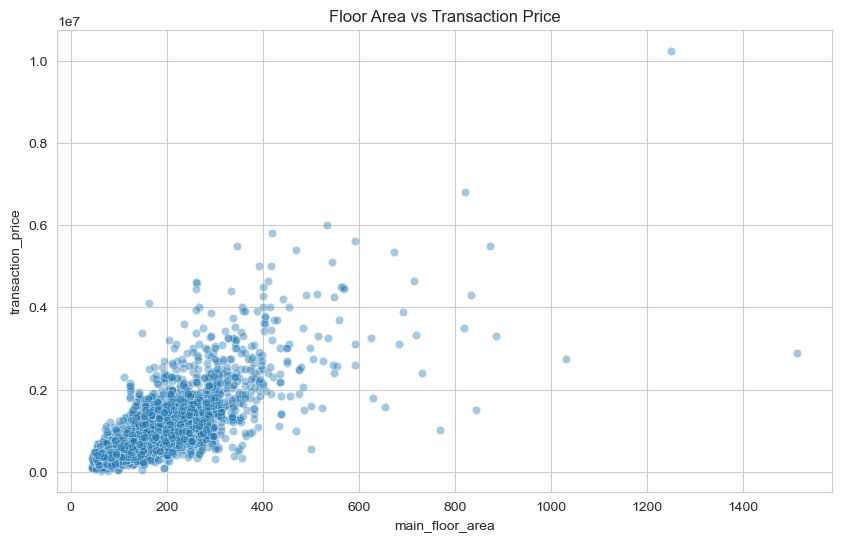

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x="main_floor_area",
    y="transaction_price",
    alpha=0.4
)

plt.title("Floor Area vs Transaction Price")

plt.show()

**CORRELATION**

In [27]:
corr = df[
    ["main_floor_area", "transaction_price"]
].corr()

print(corr)

                   main_floor_area  transaction_price
main_floor_area           1.000000           0.450094
transaction_price         0.450094           1.000000


**HEATMAP**

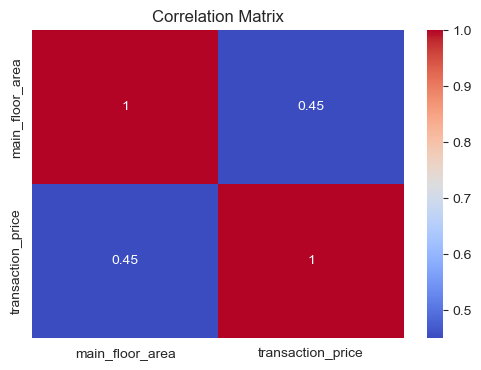

In [28]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## **PRICE PER SQUARE METER** ##

In [29]:
df["price_per_sqm"] = (
    df["transaction_price"] /
    df["main_floor_area"]
)

df["price_per_sqm"].describe()

count     70951.000000
mean       5014.062657
std        2037.539474
min         106.389636
25%        3756.906077
50%        4675.324675
75%        5831.168831
max      106716.216216
Name: price_per_sqm, dtype: float64

**TOP DISTRICT**

In [30]:
ppsm = (
    df.groupby("district")["price_per_sqm"]
    .mean()
    .sort_values(ascending=False)
)

ppsm

district
Petaling          6474.006298
Hulu Langat       4940.489507
Klang             4725.451110
Gombak            4720.577686
Sepang            4652.161105
Kuala Langat      4433.282472
Kuala Selangor    3968.963156
Hulu Selangor     3368.488164
Sabak Bernam      3294.227954
Name: price_per_sqm, dtype: float64

**BARPLOT**

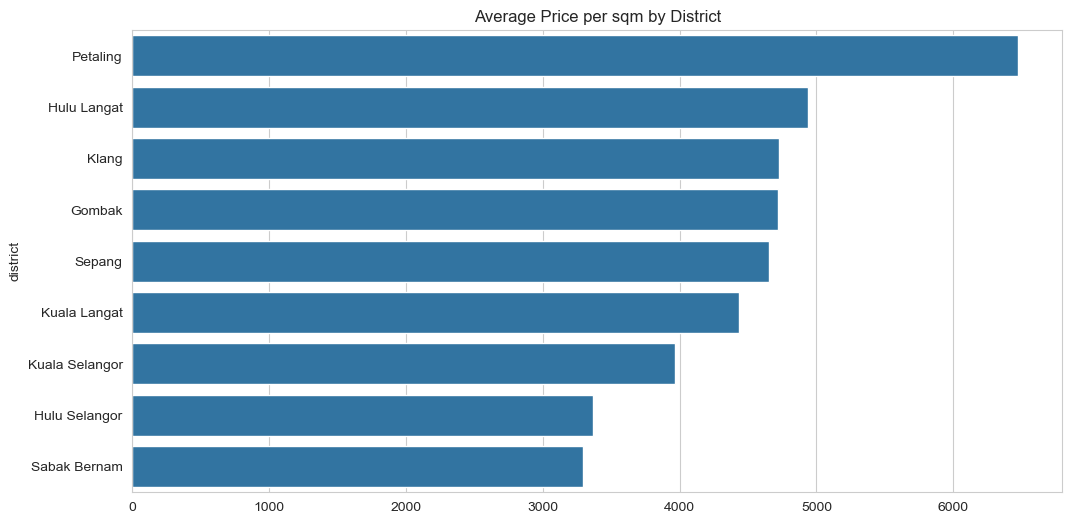

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=ppsm.values,
    y=ppsm.index
)

plt.title("Average Price per sqm by District")

plt.show()

## **TIME SERIES ANALYSIS** ##

**CONVERT DATE**

In [32]:
df["month_year_of_transaction_date"] = pd.to_datetime(
    df["month_year_of_transaction_date"],
    format="%B %Y"
)

**MONTHLY TRANSACTIONS**

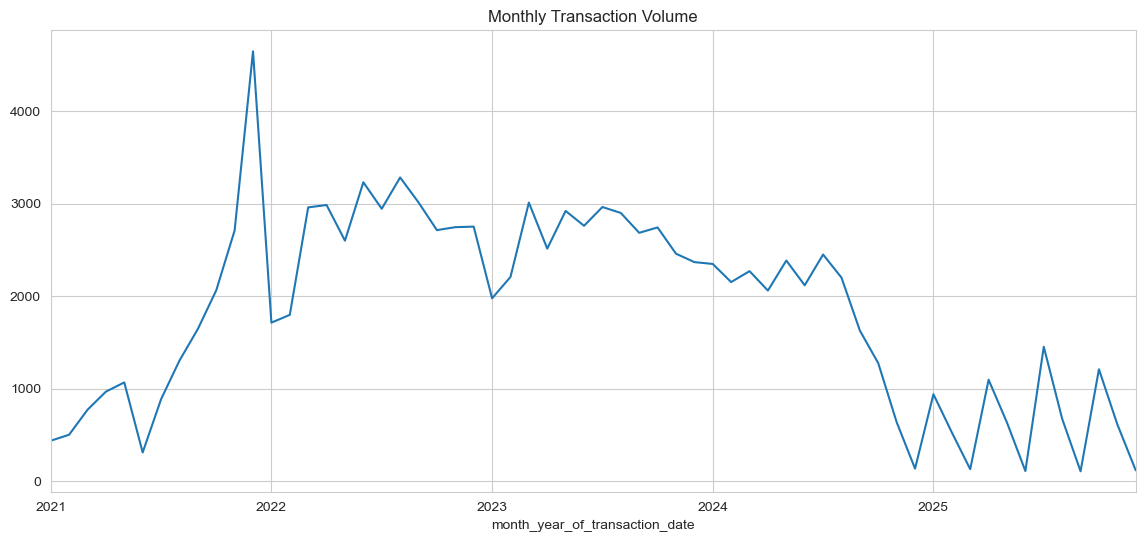

In [33]:
monthly_sales = (
    df.groupby("month_year_of_transaction_date")
    .size()
)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Transaction Volume")

plt.show()

**MONTHLY AVERAGE PRICE**

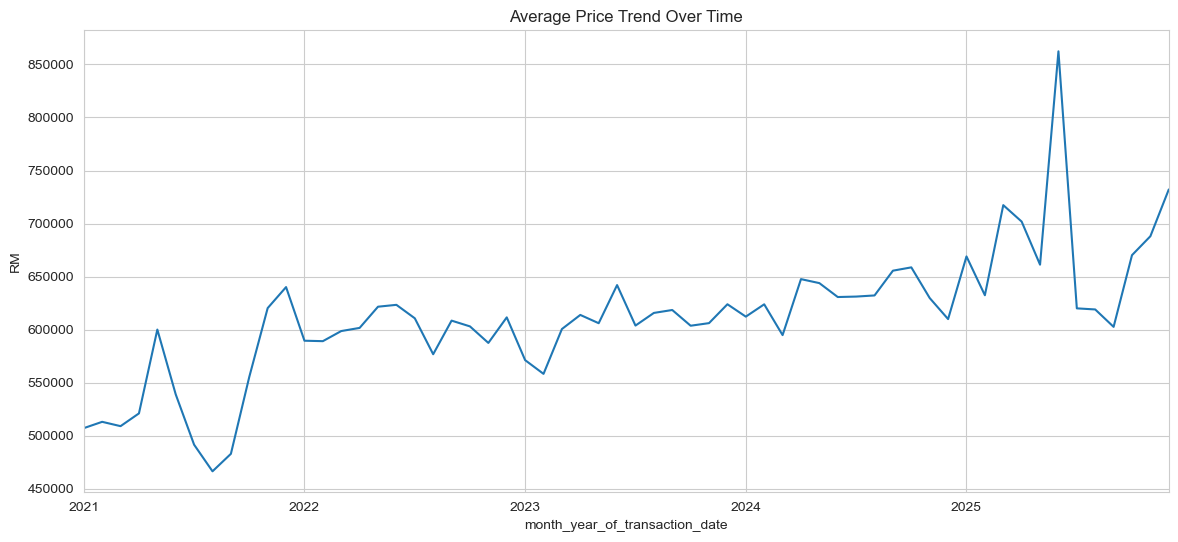

In [34]:
monthly_price = (
    df.groupby("month_year_of_transaction_date")
    ["transaction_price"]
    .mean()
)

plt.figure(figsize=(14,6))

monthly_price.plot()

plt.title("Average Price Trend Over Time")

plt.ylabel("RM")

plt.show()

## **BUSINESS INSIGHTS TABLE** ##

In [35]:
summary = pd.DataFrame({
    "Average Price":
        df.groupby("district")["transaction_price"].mean(),

    "Median Price":
        df.groupby("district")["transaction_price"].median(),

    "Transactions":
        df.groupby("district").size()
})

summary.sort_values(
    "Average Price",
    ascending=False
)

,Average Price,Median Price,Transactions
district,,,
Petaling,753370.913224,550000.0,33431
Sepang,648984.995092,558000.0,7131
Gombak,583585.475316,443000.0,12255
Hulu Langat,560903.472864,440000.0,22719
Klang,557096.090234,450000.0,18441
Kuala Langat,532607.856770,435000.0,5753
Kuala Selangor,492909.809485,450000.0,4934
Sabak Bernam,403493.455497,353000.0,764
Hulu Selangor,292416.713300,260000.0,5361
